# Section 4 : Learn & Teach — Time Series Modelling
### Topic: *Is it really possible to predict the future?*
---

## Phase 1 : Learning Log

*(Informal notes on how I actually learned this — what I searched, what confused me, what made it click)*

---

**Where I started:**
I genuinely didn't know what time series modelling was before this. My first search was literally *"what is time series data"* and I got a bunch of definitions about data points indexed by time. That made sense — stock prices, temperature readings, energy consumption. They're all just measurements taken one after another.

**What confused me first:**
Everyone kept talking about *stationarity* and I had no idea what that meant. I read three articles and none of them explained it in plain terms. Eventually what clicked was this analogy: if you're trying to predict where a ball will land, it helps if the ball is rolling on a flat surface (stationary) rather than rolling downhill (non-stationary). A non-stationary series has a trend or changing variance — which makes it harder to model because the "rules" keep shifting.

**What made it click:**
I stopped reading theory and started looking at actual plots of time series. Seeing a temperature curve that goes up in summer and down in winter made *seasonality* make sense immediately. Seeing stock prices that drift upward made *trend* obvious. Once I could see these things visually, the maths behind them felt like it was just trying to describe what I already understood intuitively.

**The big question — can you actually predict the future?**
This is what I found most interesting. The honest answer is: *sometimes, and within limits.* Some systems are genuinely predictable — sunrise times, seasonal temperature patterns, electricity demand on a Monday morning. Others are fundamentally unpredictable — exact stock prices, earthquake timing, when a machine will fail. The models don't tell you what *will* happen, they tell you what's *likely* based on what happened before. That's a much more humble and honest framing.

**What I'd still like to understand better:**
LSTM networks for time series. I understand the basic idea — they have memory, which makes them useful for sequences — but I haven't actually built one yet.

---
## Phase 2 : Teaching Resource
### *Can You Really Predict the Future? A Beginner's Guide to Time Series Modelling*

---

### The Short Answer

Yes — but only for systems that follow patterns. And no — for systems that are genuinely random.

The interesting part is figuring out which is which.

---

### What Is a Time Series?

A time series is just any sequence of measurements taken over time.

- Temperature at 9am, 10am, 11am...
- Monthly electricity consumption
- Daily solar generation
- Your heart rate every second

The key feature: **order matters**. Unlike a regular dataset where row 50 has nothing to do with row 49, in a time series, yesterday's value directly influences today's.

---

### What Makes a Time Series Predictable?

A time series is predictable if it has **structure**. Structure comes in three forms:

| Component | What it means | Example |
|-----------|---------------|----------|
| **Trend** | Long-term drift up or down | Global temperatures rising over decades |
| **Seasonality** | Regular repeating patterns | Electricity spikes every summer |
| **Autocorrelation** | Today's value resembles yesterday's | Indoor temperature stays stable for hours |

If your data has these, a model can learn them. If your data is pure noise — no structure at all — no model will help you.

---

### The Prediction vs Randomness Debate

**Argument FOR prediction being possible:**
- Physical systems follow laws. Temperature doesn't jump from 30°C to 5°C in a minute.
- Human behaviour is habitual. People use more electricity on cold evenings, every week.
- Energy consumption data from yesterday is genuinely useful for planning tomorrow's grid dispatch.
- Weather forecasts work — not perfectly, but they're far better than random guessing.

**Argument AGAINST perfect prediction:**
- Complex systems have chaos — tiny changes in starting conditions lead to wildly different outcomes.
- Events outside the model (a storm, a factory shutdown, human decisions) can break any pattern.
- Models are trained on the past. If the future is structurally different from the past, the model fails.
- Even great models degrade over time — the world changes, the model doesn't.

**The honest position:** Prediction is about reducing uncertainty, not eliminating it. A good model doesn't say *"the temperature will be exactly 31°C at 3pm"* — it says *"based on past patterns, 30–33°C is likely, and here's the confidence interval."*

---

### How Models Actually Work — Intuition Only

**Moving Average** — *"Look at the last N readings and average them"*
Simple but surprisingly useful for smoothing out noise. Not great for forecasting ahead.

**ARIMA** — *"The future is a weighted combination of the recent past"*
The classic statistical approach. It assumes the series is stationary (no trend, stable variance). Works well for short-term forecasts on well-behaved data.

**Random Forest / ML models** — *"Learn complex non-linear patterns from many features"*
You feed it time-based features (hour of day, day of week, month, lag values) and it figures out the relationships itself. Works surprisingly well in practice.

**LSTM (Deep Learning)** — *"A neural network with memory"*
Can capture long-range dependencies in sequences. Overkill for simple problems, but powerful for complex ones.

---

### Why This Matters for Energy Systems

In energy and automation, time series forecasting is everywhere:
- **Load forecasting** — predict tomorrow's electricity demand so the grid isn't over/under-supplied
- **Solar generation forecasting** — anticipate how much solar will be available to plan battery dispatch
- **Anomaly detection** — if today's consumption is way off the predicted pattern, something is wrong
- **Predictive maintenance** — detect early signals that equipment is about to fail

The value isn't in perfect prediction. It's in making better decisions under uncertainty.

---

### The One-Line Summary

> *Time series modelling doesn't predict the future — it extrapolates the past. That's useful precisely because the future often looks a lot like the past.*

---
## Demonstration — Time Series on Real Energy Data

To make this concrete, I'll demonstrate a simple time series analysis and forecast on the Shunya House energy consumption data from Section 2.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

URL = 'https://raw.githubusercontent.com/sabr6906i/Energy-Automation/refs/heads/main/Grid_logic%20-%20output%20(1).csv.csv'
df = pd.read_csv(URL)
df['timestamps'] = pd.to_datetime(df['timestamps'], utc=True)
df = df.sort_values('timestamps').reset_index(drop=True)

print('Shape:', df.shape)
df.head()

Shape: (96, 5)


,timestamps,Import rate (Rs/unit),Export rate (Rs/unit),Solar generation (unit),Electricity Consumption(unit)
0,2024-08-24 07:00:00+00:00,0.1247,0.0556,0.0,1.015
1,2024-08-24 07:15:00+00:00,0.1247,0.0556,0.0,1.002
2,2024-08-24 07:30:00+00:00,0.1247,0.0556,0.0,1.172
3,2024-08-24 07:45:00+00:00,0.1247,0.0556,0.0,1.081
4,2024-08-24 08:00:00+00:00,0.1247,0.0554,0.0,1.004


### Step 1 — Visualise the Time Series

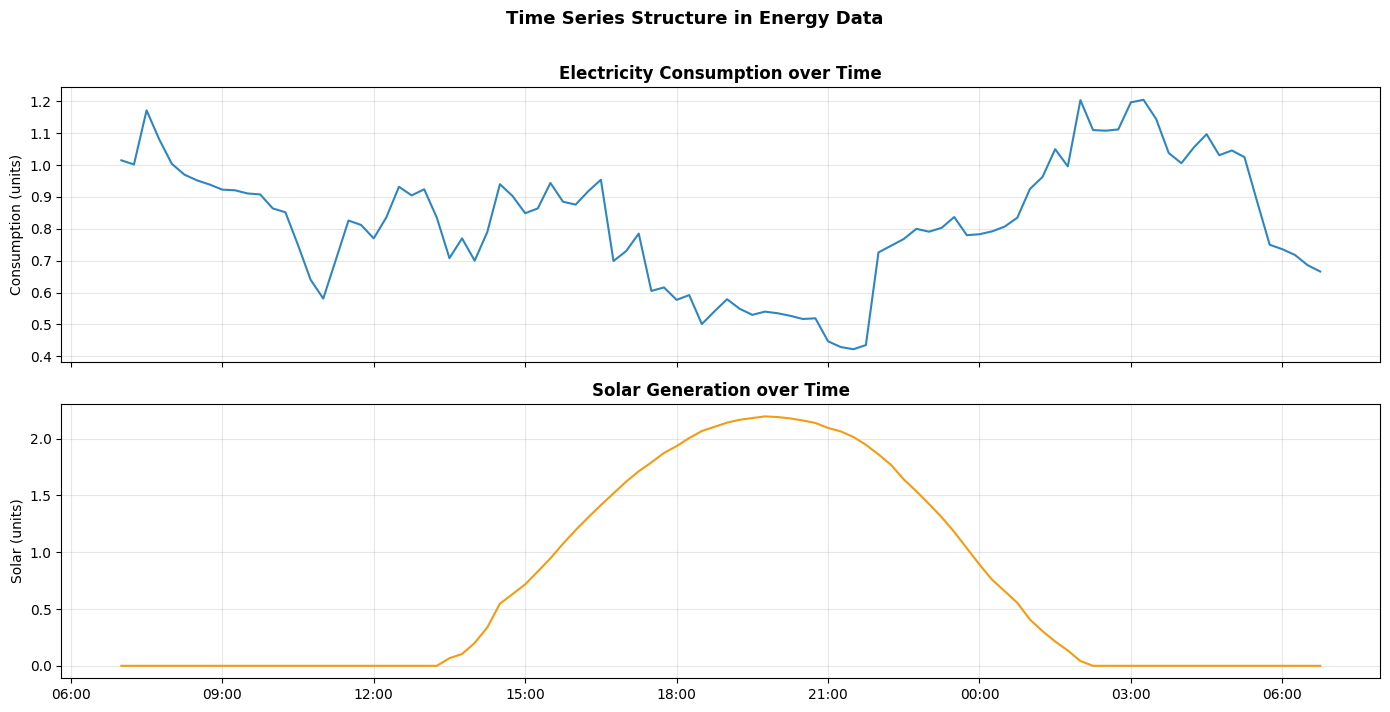

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df['timestamps'], df['Electricity Consumption(unit)'], color='#2E86C1', linewidth=1.5)
axes[0].set_title('Electricity Consumption over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Consumption (units)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['timestamps'], df['Solar generation (unit)'], color='#F39C12', linewidth=1.5)
axes[1].set_title('Solar Generation over Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Solar (units)')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.suptitle('Time Series Structure in Energy Data', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Step 2 — Decompose the Series

Classic time series decomposition splits a series into: **Trend + Seasonality + Residual (noise)**

In [15]:
import sys
!"{sys.executable}" -m pip3 install statsmodels

/usr/bin/python3: No module named pip3


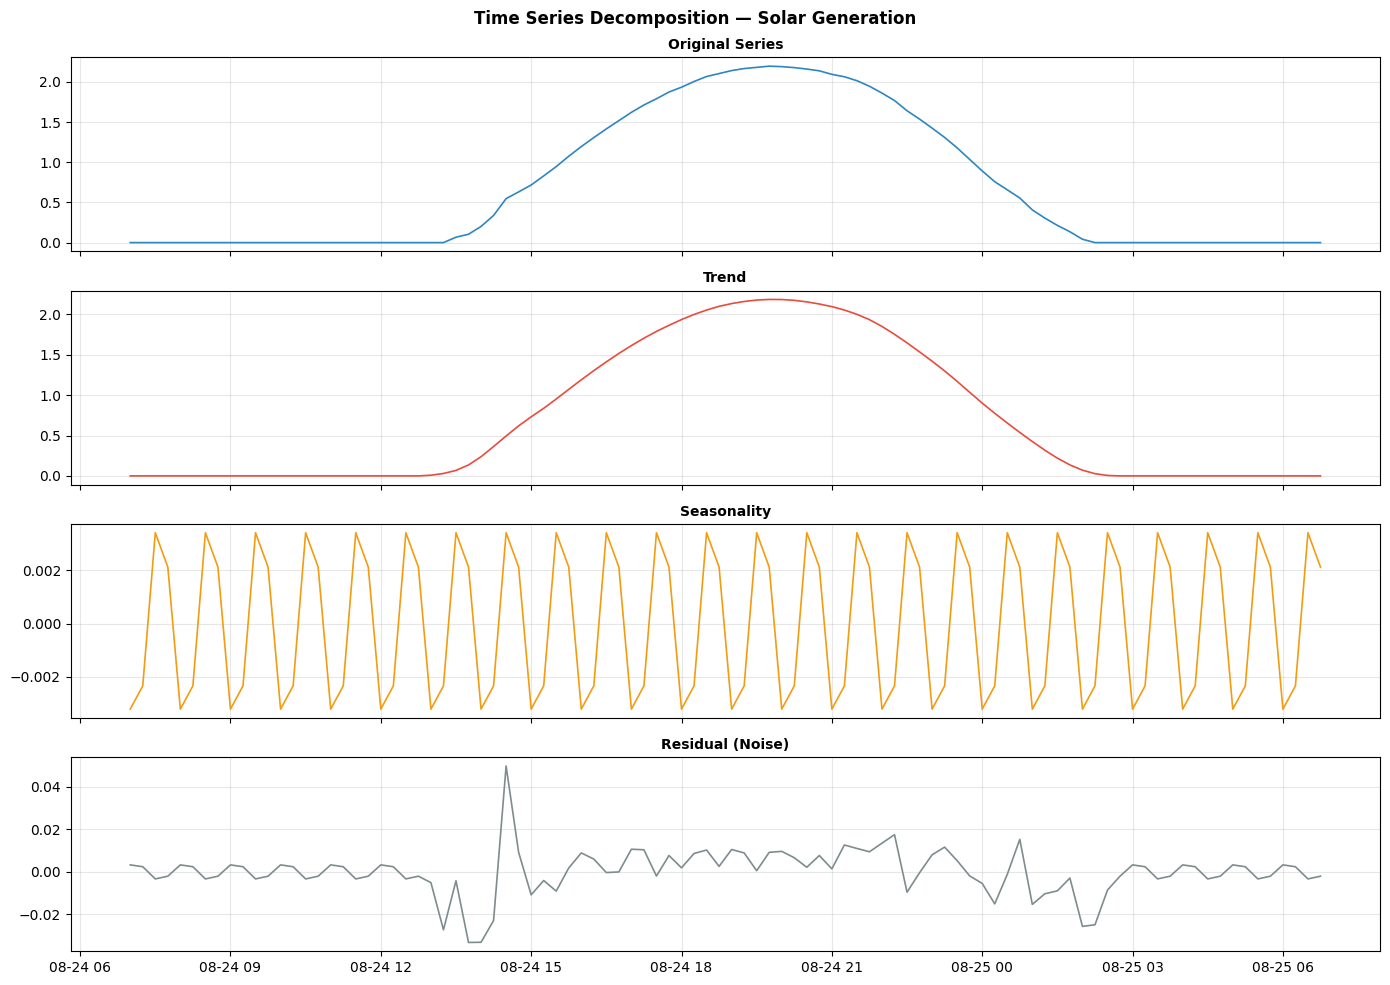

In [19]:

from statsmodels.tsa.seasonal import seasonal_decompose

# Use solar generation — has clear daily pattern
solar_series = df.set_index('timestamps')['Solar generation (unit)']

# Decompose with period = 4 (hourly pattern within 15-min slots)
decomp = seasonal_decompose(solar_series, model='additive', period=4, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    (solar_series, 'Original Series', '#2E86C1'),
    (decomp.trend, 'Trend', '#E74C3C'),
    (decomp.seasonal, 'Seasonality', '#F39C12'),
    (decomp.resid, 'Residual (Noise)', '#7F8C8D'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.2)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Time Series Decomposition — Solar Generation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3 — Autocorrelation

Autocorrelation tells us: *does knowing the value at time T help predict the value at time T+1?*  
If yes, the series has memory — and is therefore predictable.

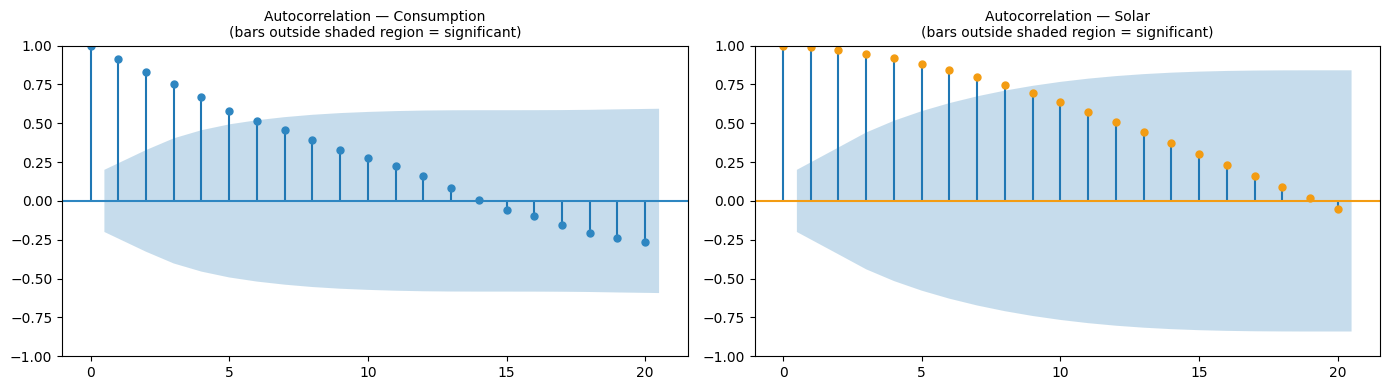

Lag-1 autocorrelation (Consumption): 0.9226
Lag-1 autocorrelation (Solar): 0.9965

Strong autocorrelation = the series has memory = it is predictable.


In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['Electricity Consumption(unit)'], lags=20, ax=axes[0], color='#2E86C1')
axes[0].set_title('Autocorrelation — Consumption\n(bars outside shaded region = significant)', fontsize=10)

plot_acf(df['Solar generation (unit)'], lags=20, ax=axes[1], color='#F39C12')
axes[1].set_title('Autocorrelation — Solar\n(bars outside shaded region = significant)', fontsize=10)

plt.tight_layout()
plt.show()

print('Lag-1 autocorrelation (Consumption):', round(df["Electricity Consumption(unit)"].autocorr(lag=1), 4))
print('Lag-1 autocorrelation (Solar):', round(df["Solar generation (unit)"].autocorr(lag=1), 4))
print()
print('Strong autocorrelation = the series has memory = it is predictable.')

### Step 4 — Simple Forecast Using Moving Average

The simplest forecasting model: predict the next value as the average of the last N values.

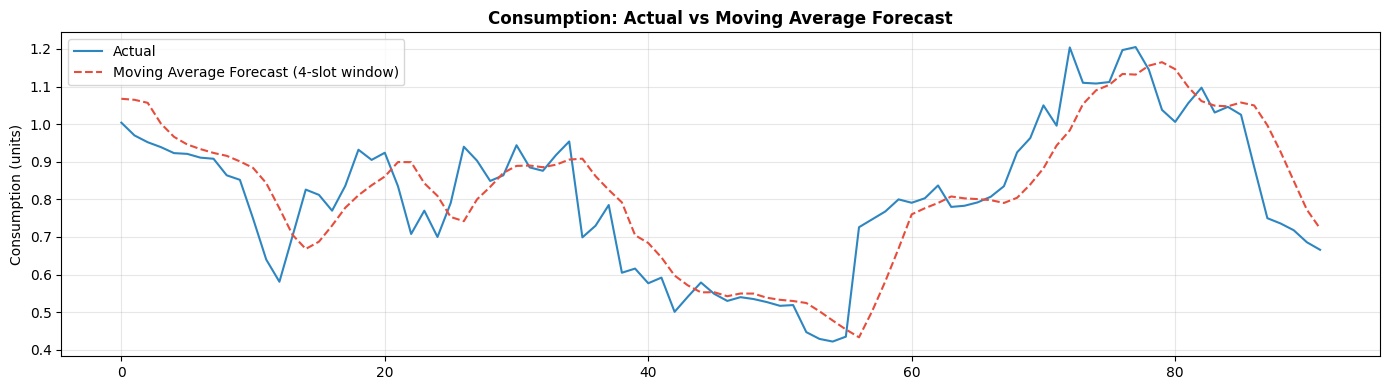

Moving Average MAE: 0.0780 units
Average consumption: 0.8232 units
Error as % of mean: 9.5%


In [18]:
from sklearn.metrics import mean_absolute_error

series = df['Electricity Consumption(unit)'].values
window = 4  # last 4 slots = last 1 hour

# Rolling forecast
predictions = []
for i in range(window, len(series)):
    predictions.append(np.mean(series[i-window:i]))

actual = series[window:]
mae    = mean_absolute_error(actual, predictions)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(len(actual)), actual,      color='#2E86C1', linewidth=1.5, label='Actual')
ax.plot(range(len(predictions)), predictions, color='#E74C3C', linewidth=1.5, linestyle='--', label='Moving Average Forecast (4-slot window)')
ax.set_title('Consumption: Actual vs Moving Average Forecast', fontsize=12, fontweight='bold')
ax.set_ylabel('Consumption (units)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Moving Average MAE: {mae:.4f} units')
print(f'Average consumption: {np.mean(series):.4f} units')
print(f'Error as % of mean: {mae/np.mean(series)*100:.1f}%')

### Step 5 — The Verdict

From the analysis above:
- Both consumption and solar have **strong autocorrelation** — meaning past values genuinely predict future values
- The decomposition shows **clear seasonality** (daily patterns) and **stable residuals**
- Even a simple 1-hour moving average achieves a small MAE — so yes, short-term prediction works well here

**But** — this is a single day of data with relatively stable conditions. Over months, consumption patterns would shift, and solar would change with seasons. The predictability degrades as you look further ahead.

> **Final answer to the question:** Yes, you can predict the future — for well-structured physical systems, over short time horizons, with appropriate uncertainty bounds. The further ahead you look, the more honest you have to be about what you don't know.